# Multiple Linear Regression with Backward Elimination on Vaccination Dataset

In [1]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
file_path = r"cleaned_vaccinations.csv"
df = pd.read_csv(file_path)
df.head()

,location,date,total_vaccinations_per_hundred,total_vaccinations,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,daily_vaccinations_per_million,daily_people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred.1
0,Afghanistan,2021-05-11,1.23,504502.0,1.09,0.14,0.0,338.0,0.027,0.14
1,Afghanistan,2021-05-20,1.33,547901.0,1.14,0.19,0.0,117.0,0.006,0.19
2,Afghanistan,2021-05-24,1.39,573277.0,1.16,0.24,0.0,138.0,0.005,0.24
3,Afghanistan,2021-05-26,1.44,590454.0,1.17,0.27,0.0,165.0,0.004,0.27
4,Afghanistan,2021-05-27,1.44,593313.0,1.17,0.28,0.0,158.0,0.003,0.28


In [ ]:
# Define Features (X) and Target (y)
X = df[[
    'total_vaccinations_per_hundred', 'total_vaccinations', 
    'people_vaccinated_per_hundred', 'total_boosters_per_hundred', 
    'daily_vaccinations_per_million', 'daily_people_vaccinated_per_hundred'
]]
y = df['people_fully_vaccinated_per_hundred']

# Add constant column for OLS regression
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     OLS Regression Results                                    
===============================================================================================
Dep. Variable:     people_fully_vaccinated_per_hundred   R-squared:                       0.923
Model:                                             OLS   Adj. R-squared:                  0.923
Method:                                  Least Squares   F-statistic:                 1.254e+05
Date:                                 Mon, 25 Aug 2025   Prob (F-statistic):               0.00
Time:                                         14:16:05   Log-Likelihood:            -2.2201e+05
No. Observations:                                62980   AIC:                         4.440e+05
Df Residuals:                                    62973   BIC:                         4.441e+05
Df Model:                                            6                                         
Covariance Type:                             nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                   5.1189      0.075     67.896      0.000       4.971       5.267
total_vaccinations_per_hundred          0.2097      0.001    186.917      0.000       0.207       0.212
total_vaccinations                  -3.153e-10   1.19e-10     -2.646      0.008   -5.49e-10   -8.17e-11
people_vaccinated_per_hundred           0.4123      0.002    182.999      0.000       0.408       0.417
total_boosters_per_hundred             -0.1040      0.002    -51.262      0.000      -0.108      -0.100
daily_vaccinations_per_million      -5.171e-05   1.44e-05     -3.588      0.000      -8e-05   -2.35e-05
daily_people_vaccinated_per_hundred   -20.7783      0.284    -73.171      0.000     -21.335     -20.222
==============================================================================
Omnibus:                    34302.027   Durbin-Watson:                   0.255
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           530821.686
Skew:                           2.285   Prob(JB):                         0.00
Kurtosis:                      16.468   Cond. No.                     2.54e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.54e+09. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [12]:
# removing total_vaccinations_per_hundred	
# Define Features (X) and Target (y)
X = df[[
    'total_vaccinations', 
    'people_vaccinated_per_hundred', 'total_boosters_per_hundred', 
    'daily_vaccinations_per_million', 'daily_people_vaccinated_per_hundred'
]]
y = df['people_fully_vaccinated_per_hundred']

# Add constant column for OLS regression
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     OLS Regression Results                                    
===============================================================================================
Dep. Variable:     people_fully_vaccinated_per_hundred   R-squared:                       0.880
Model:                                             OLS   Adj. R-squared:                  0.880
Method:                                  Least Squares   F-statistic:                 9.231e+04
Date:                                 Mon, 25 Aug 2025   Prob (F-statistic):               0.00
Time:                                         14:21:16   Log-Likelihood:            -2.3591e+05
No. Observations:                                62980   AIC:                         4.718e+05
Df Residuals:                                    62974   BIC:                         4.719e+05
Df Model:                                            5                                         
Covariance Type:                             nonrobust                                         
=======================================================================================================
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                   7.9091      0.092     85.831      0.000       7.728       8.090
total_vaccinations                   1.143e-09   1.48e-10      7.707      0.000    8.52e-10    1.43e-09
people_vaccinated_per_hundred           0.7389      0.002    416.485      0.000       0.735       0.742
total_boosters_per_hundred              0.1708      0.002     97.954      0.000       0.167       0.174
daily_vaccinations_per_million          0.0002   1.79e-05     11.475      0.000       0.000       0.000
daily_people_vaccinated_per_hundred   -30.1061      0.349    -86.369      0.000     -30.789     -29.423
==============================================================================
Omnibus:                    42460.738   Durbin-Watson:                   0.273
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           820617.550
Skew:                           2.997   Prob(JB):                         0.00
Kurtosis:                      19.637   Cond. No.                     2.50e+09
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.5e+09. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Conclusion: This dataset is not suitted for linear regression 

In [15]:
# Model Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = sm.OLS(y_train, X_train).fit()
y_pred = model.predict(X_test)

print("\nModel Evaluation:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))


Model Evaluation:
Mean Squared Error: 850.4964052635675
R² Score: 0.024671706376770852


# Random Forest

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
file_path = r'cleaned_vaccinations.csv'
df = pd.read_csv(file_path)
df.head()

,location,date,total_vaccinations_per_hundred,total_vaccinations,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,total_boosters_per_hundred,daily_vaccinations_per_million,daily_people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred.1
0,Afghanistan,2021-05-11,1.23,504502.0,1.09,0.14,0.0,338.0,0.027,0.14
1,Afghanistan,2021-05-20,1.33,547901.0,1.14,0.19,0.0,117.0,0.006,0.19
2,Afghanistan,2021-05-24,1.39,573277.0,1.16,0.24,0.0,138.0,0.005,0.24
3,Afghanistan,2021-05-26,1.44,590454.0,1.17,0.27,0.0,165.0,0.004,0.27
4,Afghanistan,2021-05-27,1.44,593313.0,1.17,0.28,0.0,158.0,0.003,0.28


In [3]:
# Convert 'date' to a numerical feature (ordinal)
df['date'] = pd.to_datetime(df['date'])
df['date_ordinal'] = df['date'].apply(lambda date: date.toordinal())

In [4]:
# Convert 'location' to a numerical feature (category code)
df['location_code'] = df['location'].astype('category').cat.codes

In [5]:
# Drop rows where the target variable is missing
df.dropna(subset=['total_vaccinations_per_hundred'], inplace=True)

In [6]:
# Select features (X) and the target variable (y)
features = [
    'date_ordinal',
    'location_code',
    'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred',
    'total_boosters_per_hundred',
    'daily_vaccinations_per_million',
]
target = 'total_vaccinations_per_hundred'

X = df[features]
y = df[target]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
model = RandomForestRegressor(random_state=42)

In [9]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = model.predict(X_test)

In [11]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [12]:
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 77.8051
R-squared (R²): 0.9893


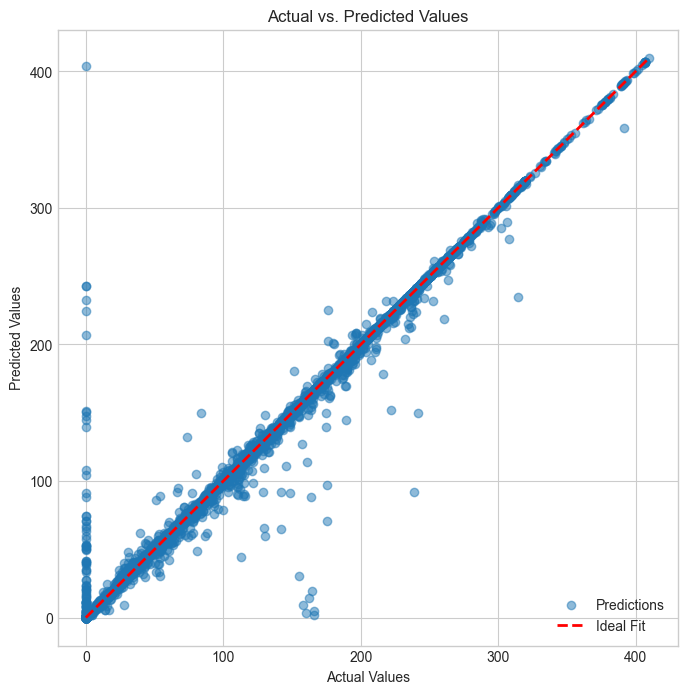

In [13]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred, alpha=0.5, label='Predictions')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, color='red', label='Ideal Fit')
ax.set_xlabel("Actual Values")
ax.set_ylabel("Predicted Values")
ax.set_title(f"Actual vs. Predicted Values")
ax.legend()
plt.show()